In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [54]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib.pyplot as plt

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [4]:
# Create custom gates
H_matrix = HGate().to_matrix()
hadamard_custom = UnitaryGate(H_matrix, label='hadamard_custom')

ID_matrix = IGate().to_matrix()
encoding_err = UnitaryGate(ID_matrix, label='encoding_err')

idle_matrix = IGate().to_matrix()
idle = UnitaryGate(idle_matrix, label='idle')

ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

# Circuit

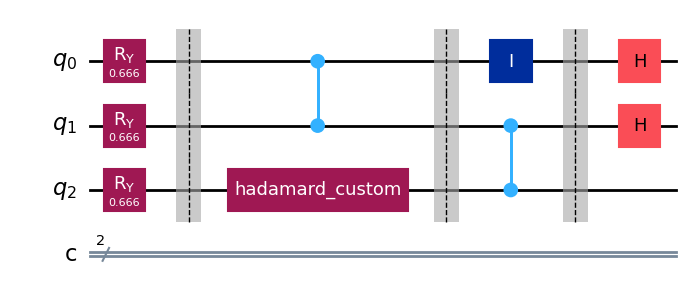

In [6]:
circuit = QuantumCircuit(3, 2)

# State prep
for i in range(3):
    circuit.ry(theta, i)
circuit.barrier()

circuit.cz(0,1)
circuit.append(hadamard_custom, [2])
circuit.barrier()

circuit.id(0)
circuit.cz(1,2)
circuit.barrier()

circuit.h(0)
circuit.h(1)

display(circuit.draw(output='mpl'))

# Infidelity to Error Rates

In [7]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [8]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [9]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

In [23]:
# Ideal dm
one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal = np.kron(one_q_zero_dm, np.kron(one_q_zero_dm, one_q_zero_dm))

ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])
ry_i_i = np.kron(ry_theta, np.kron(np.eye(2), np.eye(2)))

ideal = ry_i_i @ ideal @ ry_i_i.conj().T
ideal /= np.trace(ideal)
ideal = DensityMatrix(ideal)

In [55]:
all_fidelity = []
all_fidelity_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()

    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])

    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    all_fidelity.append(sumfid)
    all_fidelity_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )

all_infidelity = [1-f for f in all_fidelity]

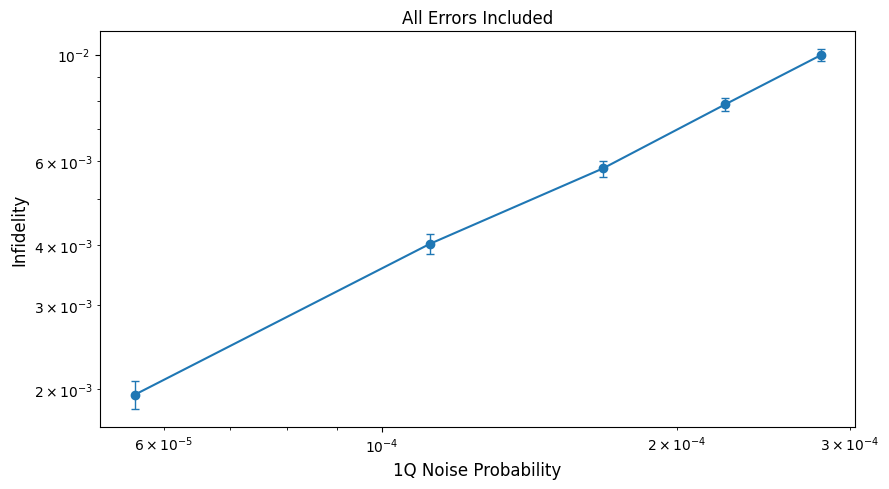

In [56]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1
)
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.title("All Errors Included")
plt.tight_layout()
plt.show()

Input simulations

In [26]:
one_q_zero_dm = np.matmul([[1], [0]], [[1,0]])
ideal_input = ry_theta @ one_q_zero_dm @ ry_theta.conj().T

ideal_input /= np.trace(ideal_input)
ideal_input = DensityMatrix(ideal_input)

In [27]:
input_circuit = QuantumCircuit(1)
input_circuit.ry(theta,0)

In [28]:
all_input_fidelity = []
shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    nm = NoiseModel()
    
    nm.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    input_copy = input_circuit.copy()
    input_copy.append(SaveDensityMatrix(num_qubits=1, label='dm_post', conditional=True, pershot=True), input_copy.qubits)
    
    backend = AerSimulator(noise_model=nm, method='density_matrix')
    job = backend.run(input_copy, shots=shots)
    result = job.result()

    res_density_matrix = result.data()['dm_post']
    
    all_input_fidelity.append(state_fidelity(ideal_input, res_density_matrix[''][0]))

all_input_infidelity = [1-f for f in all_input_fidelity]

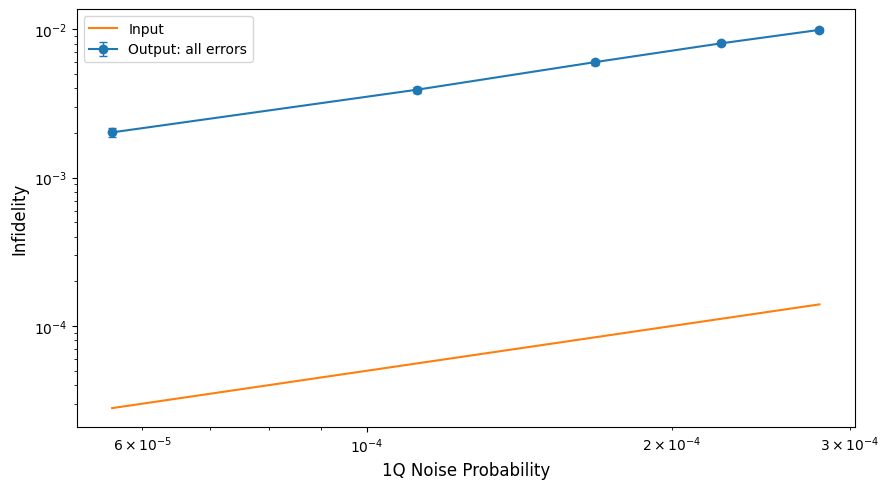

In [41]:
plt.figure(figsize=(9, 5))
plt.errorbar(
    one_qubit_gate_error_prob,
    all_infidelity,
    yerr=all_fidelity_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1,
    label='Output: all errors'
)
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()

# What is the success probability

In [ ]:
shots = 100_000
success_prob_list = []

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()

    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])

    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas00 = len(res_statevectors['0x0'])
    num_success = 0
    for shot in res_statevectors['0x0']:
        fid = state_fidelity(shot, ideal)
        if (round(fid, 2) == 1.00):
            num_success += 1 
            
    success_prob_list.append(num_success / num_meas00)

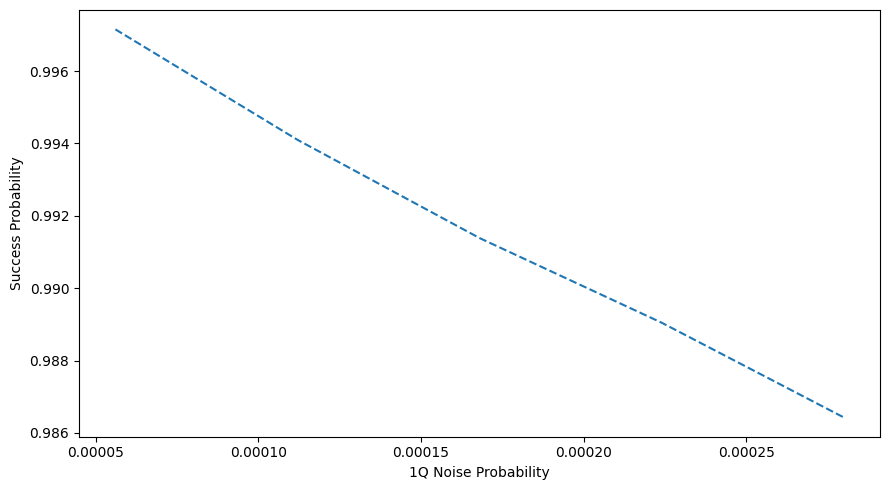

In [45]:
plt.figure(figsize=(9,5))
plt.plot(one_qubit_gate_error_prob, success_prob_list, linestyle='--')
plt.xlabel('1Q Noise Probability')
plt.ylabel('Success Probability')
plt.tight_layout()
plt.show()

# Circuit Component Analysis

In [46]:
# Entire distillation circuit is ideal
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ["ry"])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot1_y = [1 - f for f in fidelity_results]

In [47]:
# Disregard measurement errors
fidelity_results = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity_results.append(state_fidelity(ideal, res_dm['0x0'][0]))
    
plot2_y = [1 - f for f in fidelity_results]

In [ ]:
# Disregard idling errors
fidelity_results = []
plot3_y_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results.append(sumfid)
    plot3_y_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )
    
plot3_y = [1 - f for f in fidelity_results]

In [ ]:
# Disregard cz errors
fidelity_results = []
plot4_y_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results.append(sumfid)
    plot4_y_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )
    
plot4_y = [1 - f for f in fidelity_results]

In [ ]:
# Disregard hadamard errors
fidelity_results = []
plot5_y_unc = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, ideal)
    sumfid /= num_meas
    
    fidelity_results.append(sumfid)
    plot5_y_unc.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )
    
plot5_y = [1 - f for f in fidelity_results]

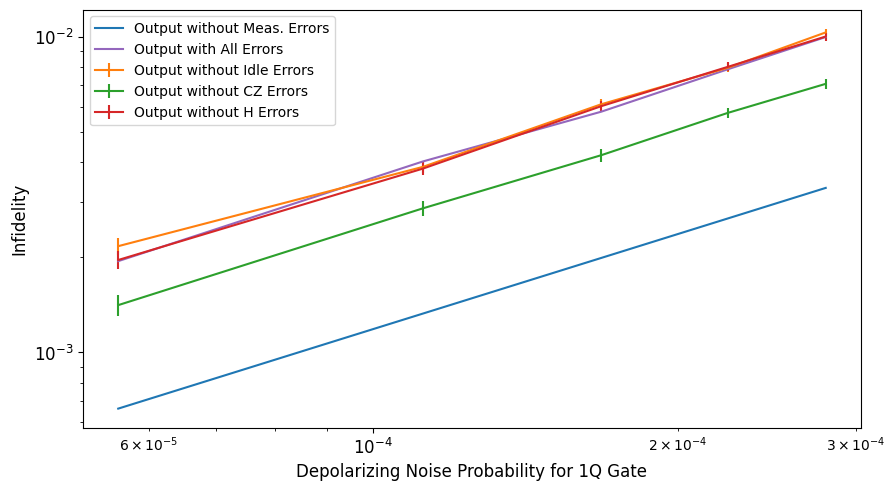

In [58]:
# Every plot without input and ideal circuit
plt.figure(figsize=(9,5))

plt.plot(one_qubit_gate_error_prob, plot2_y, label='Output without Meas. Errors')
plt.errorbar(one_qubit_gate_error_prob, plot3_y, yerr=plot3_y_unc, label='Output without Idle Errors')
plt.errorbar(one_qubit_gate_error_prob, plot4_y, yerr=plot4_y_unc, label='Output without CZ Errors')
plt.errorbar(one_qubit_gate_error_prob, plot5_y, yerr=plot5_y_unc, label='Output without H Errors')
plt.plot(one_qubit_gate_error_prob, all_infidelity, label='Output with All Errors')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

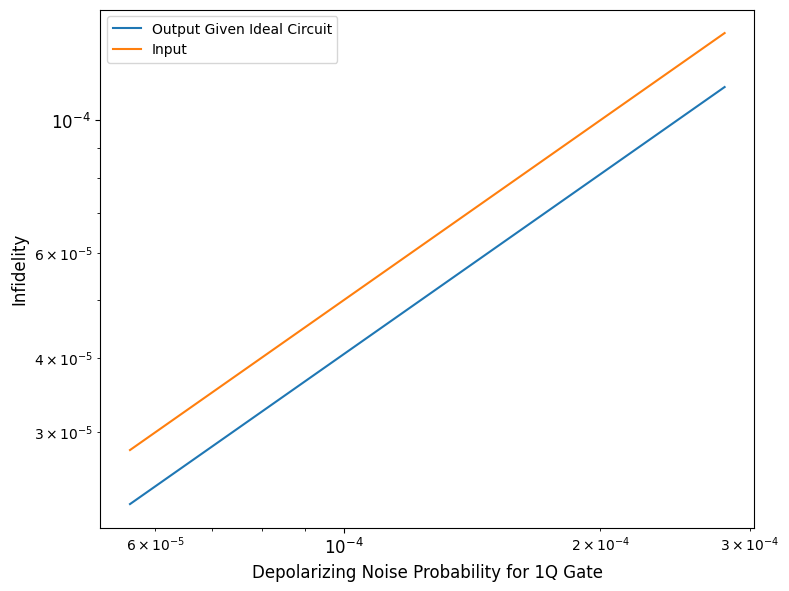

In [57]:
# Plotting both together
plt.figure(figsize=(8,6))

plt.plot(one_qubit_gate_error_prob, plot1_y, label='Output Given Ideal Circuit')
plt.plot(one_qubit_gate_error_prob, all_input_infidelity, label='Input')

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Depolarizing Noise Probability for 1Q Gate', fontsize=12)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

calcualting each components contribution to the total noise

In [59]:
# Finding rho_ideal for each depolarizing noise probability
rho_ideal_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    rho_ideal_list.append(res_dm['0x0'][0])

In [61]:
# Only hadamard errors
c_h_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['hadamard_custom'])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity = state_fidelity(rho_ideal_list[i], res_dm['0x0'][0])
    c_h_infidelity_list.append(1-fidelity)

In [63]:
# Only idling errors
c_id_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(idle_gate_error_prob[i], 1), ['id'])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity = state_fidelity(rho_ideal_list[i], res_dm['0x0'][0])
    c_id_infidelity_list.append(1-fidelity)

In [65]:
# Only CZ errors
c_cz_infidelity_list = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_gate_error_prob[i], 2), ['cz']) 
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveDensityMatrix(num_qubits=3, label='dm_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_dm = result.data()['dm_post']
    fidelity = state_fidelity(rho_ideal_list[i], res_dm['0x0'][0])
    c_cz_infidelity_list.append(1-fidelity)

In [67]:
# Only measurement errors
c_meas_infidelity_list = []
c_meas_infidelity_unc_list = []
shots = 1_000_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
        
    noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_gate_error_prob[i], 1), ['ry'])
    
    readout_err = ReadoutError([[1-spam0[i], spam0[i]],  # P(0|0), P(1|0)
                            [spam1[i], 1-spam1[i]]]) # P(0|1), P(1|1)
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    meas_circuit_noise = circuit.copy()
    meas_circuit_noise.measure([0, 1], [0, 1]) 
    meas_circuit_noise.append(SaveStatevector(num_qubits=3, label='state_post', conditional=True, pershot=True), meas_circuit_noise.qubits)

    backend = AerSimulator(noise_model=noise_model)
    job = backend.run(meas_circuit_noise, shots=shots)
    result = job.result()
    
    res_statevectors = result.data()['state_post']
    num_meas = len(res_statevectors['0x0'])
    sumfid = 0
    for shot in res_statevectors['0x0']:
        sumfid += state_fidelity(shot, rho_ideal_list[i])
    sumfid /= num_meas
    
    c_meas_infidelity_list.append(1-sumfid)
    c_meas_infidelity_unc_list.append( 1.96 * np.sqrt( (sumfid)*(1 - sumfid) / num_meas) )

In [70]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(c_h_infidelity_list[i] + c_id_infidelity_list[i] + c_cz_infidelity_list[i] + c_meas_infidelity_list[i])

for i, e in enumerate(one_qubit_gate_error_prob):
    print(f"For 1Q error probability = {e}")
    print(f"Hadamard Fractions = {c_h_infidelity_list[i] / sum_c_list[i]}")
    print(f"Idling Fractions = {c_id_infidelity_list[i] / sum_c_list[i]}")
    print(f"CZ Fractions = {c_cz_infidelity_list[i] / sum_c_list[i]}")
    print(f"Measurement Fractions = {c_meas_infidelity_list[i] / sum_c_list[i]}")
    print("")

For 1Q error probability = 5.6e-05
Hadamard Fractions = 0.00128257418298398
Idling Fractions = 6.22517374235803e-05
CZ Fractions = 0.22326606223379222
Measurement Fractions = 0.7753891118458003

For 1Q error probability = 0.000112
Hadamard Fractions = 0.001335419377476325
Idling Fractions = 6.492559502269932e-05
CZ Fractions = 0.23252344895261978
Measurement Fractions = 0.7660762060748812

For 1Q error probability = 0.000168
Hadamard Fractions = 0.001359613544803956
Idling Fractions = 6.621281469420219e-05
CZ Fractions = 0.23679540425394452
Measurement Fractions = 0.7617787693865573

For 1Q error probability = 0.000224
Hadamard Fractions = 0.0013195885208783398
Idling Fractions = 6.437132103605005e-05
CZ Fractions = 0.2298819440226283
Measurement Fractions = 0.7687340961354573

For 1Q error probability = 0.00028
Hadamard Fractions = 0.0013381758388617655
Idling Fractions = 6.538730291400679e-05
CZ Fractions = 0.23317817693959708
Measurement Fractions = 0.7654182599186271



In [72]:
# Saving Data
np.savez("physical_level_component_analysis.npz",
    plot1_y=plot1_y,
    plot2_y=plot2_y,
    plot3_y=plot3_y,
    plot3_y_unc=plot3_y_unc,
    plot4_y=plot4_y,
    plot4_y_unc=plot4_y_unc,
    plot5_y=plot5_y,
    plot5_y_unc=plot5_y_unc,
    all_input_infidelity=all_input_infidelity,
    all_infidelity=all_infidelity,
    c_h_infidelity_list=c_h_infidelity_list,
    c_id_infidelity_list=c_id_infidelity_list,
    c_cz_infidelity_list=c_cz_infidelity_list,
    c_meas_infidelity_list=c_meas_infidelity_list,
    c_meas_infidelity_unc_list=c_meas_infidelity_unc_list
)

In [ ]:
# Loading Data
data = np.load("physical_level_component_analysis.npz")
plot1_y = data["plot1_y"]
plot2_y = data["plot2_y"]
plot3_y = data["plot3_y"]
plot3_y_unc = data["plot3_y_unc"]
plot4_y = data["plot4_y"]
plot4_y_unc = data["plot4_y_unc"]
plot5_y = data["plot5_y"]
plot5_y_unc = data["plot5_y_unc"]
all_input_infidelity = data["all_input_infidelity"]
all_infidelity = data["all_infidelity"]
c_h_infidelity_list = data["c_h_infidelity_list"]
c_id_infidelity_list = data["c_id_infidelity_list"]
c_cz_infidelity_list = data["c_cz_infidelity_list"]
c_meas_infidelity_list = data["c_meas_infidelity_list"]
c_meas_infidelity_unc_list = data["c_meas_infidelity_unc_list"]